In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Read data into DataFrame
df= pd.read_csv('kidney_disease.csv')
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [3]:
df.shape

(400, 26)

In [4]:
# dropping id column
df.drop('id', axis = 1, inplace = True)

In [5]:
df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'aanemia', 'class']

In [6]:
df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [7]:
df.describe()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

In [9]:
# converting necessary columns to numerical type

df['packed_cell_volume'] = pd.to_numeric(df['packed_cell_volume'], errors='coerce')
df['white_blood_cell_count'] = pd.to_numeric(df['white_blood_cell_count'], errors='coerce')
df['red_blood_cell_count'] = pd.to_numeric(df['red_blood_cell_count'], errors='coerce')

In [18]:
# checking for null values

df.isna().sum().sort_values(ascending = False)

red_blood_cell_count       131
white_blood_cell_count     106
potassium                   88
sodium                      87
packed_cell_volume          71
haemoglobin                 52
sugar                       49
specific_gravity            47
albumin                     46
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
blood_pressure              12
age                          9
bacteria                     0
pus_cell_clumps              0
pus_cell                     0
red_blood_cells              0
hypertension                 0
diabetes_mellitus            0
coronary_artery_disease      0
appetite                     0
peda_edema                   0
aanemia                      0
class                        0
dtype: int64

In [26]:
# Replace null values with mode value, can be justed in the future!


#red_blood_cell_count
rbcc_null = df[df['red_blood_cell_count'].isnull()].index
df['red_blood_cell_count'].fillna(df['red_blood_cell_count'].mode()[0], inplace=True)

#white_blood_cell_count
wbcc_null = df[df['white_blood_cell_count'].isnull()].index
df['white_blood_cell_count'].fillna(df['white_blood_cell_count'].mode()[0], inplace=True)

#potassium
p_null = df[df['potassium'].isnull()].index
df['potassium'].fillna(df['potassium'].mode()[0], inplace=True)

#sodium
so_null = df[df['sodium'].isnull()].index
df['sodium'].fillna(df['sodium'].mode()[0], inplace=True)

#packed_cell_volume 
pcv_null = df[df['packed_cell_volume'].isnull()].index
df['packed_cell_volume'].fillna(df['packed_cell_volume'].mode()[0], inplace=True)

#haemoglobin  
h_null = df[df['haemoglobin'].isnull()].index
df['haemoglobin'].fillna(df['haemoglobin'].mode()[0], inplace=True)

#sugar
su_null = df[df['sugar'].isnull()].index
df['sugar'].fillna(df['sugar'].mode()[0], inplace=True)

#specific_gravity
sp_null = df[df['specific_gravity'].isnull()].index
df['specific_gravity'].fillna(df['specific_gravity'].mode()[0], inplace=True)

#albumin
al_null = df[df['albumin'].isnull()].index
df['albumin'].fillna(df['albumin'].mode()[0], inplace=True)

#blood_glucose_random
bgr_null = df[df['blood_glucose_random'].isnull()].index
df['blood_glucose_random'].fillna(df['blood_glucose_random'].mode()[0], inplace=True)

#blood_urea
bu_null = df[df['blood_urea'].isnull()].index
df['blood_urea'].fillna(df['blood_urea'].mode()[0], inplace=True)

#serum_creatinine
sr_null = df[df['serum_creatinine'].isnull()].index
df['serum_creatinine'].fillna(df['serum_creatinine'].mode()[0], inplace=True)

#blood_pressure
bp_null = df[df['blood_pressure'].isnull()].index
df['blood_pressure'].fillna(df['blood_pressure'].mode()[0], inplace=True)

#age
ag_null = df[df['age'].isnull()].index
df['age'].fillna(df['age'].mode()[0], inplace=True)




In [27]:
df.isna().sum().sort_values(ascending = False)

age                        0
potassium                  0
aanemia                    0
peda_edema                 0
appetite                   0
coronary_artery_disease    0
diabetes_mellitus          0
hypertension               0
red_blood_cell_count       0
white_blood_cell_count     0
packed_cell_volume         0
haemoglobin                0
sodium                     0
blood_pressure             0
serum_creatinine           0
blood_urea                 0
blood_glucose_random       0
bacteria                   0
pus_cell_clumps            0
pus_cell                   0
red_blood_cells            0
sugar                      0
albumin                    0
specific_gravity           0
class                      0
dtype: int64

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      400 non-null    float64
 1   blood_pressure           400 non-null    float64
 2   specific_gravity         400 non-null    float64
 3   albumin                  400 non-null    float64
 4   sugar                    400 non-null    float64
 5   red_blood_cells          400 non-null    object 
 6   pus_cell                 400 non-null    object 
 7   pus_cell_clumps          400 non-null    object 
 8   bacteria                 400 non-null    object 
 9   blood_glucose_random     400 non-null    float64
 10  blood_urea               400 non-null    float64
 11  serum_creatinine         400 non-null    float64
 12  sodium                   400 non-null    float64
 13  potassium                400 non-null    float64
 14  haemoglobin              4

In [29]:
# replace incorrect values

df['diabetes_mellitus'].replace(to_replace = {'\tno':'no','\tyes':'yes',' yes':'yes'},inplace=True)

df['coronary_artery_disease'] = df['coronary_artery_disease'].replace(to_replace = '\tno', value='no')

df['class'] = df['class'].replace(to_replace = {'ckd\t': 'ckd', 'notckd': 'not ckd'})

df['class'] = df['class'].map({'ckd': 0, 'not ckd': 1})

In [30]:
# Extracting categorical and numerical columns

# numerical variebles
num_cols = df.select_dtypes(exclude = 'object')
# print the numerical variebles
num_cols.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'class'],
      dtype='object')

In [31]:
# Categorical variebles 
cat_cols = df.select_dtypes(include = 'object')
cat_cols.columns

Index(['red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'hypertension', 'diabetes_mellitus', 'coronary_artery_disease',
       'appetite', 'peda_edema', 'aanemia'],
      dtype='object')

In [32]:
# one-hot encode the catogorical variebles
encoded_cat_cols = pd.get_dummies(cat_cols)
df = pd.concat([num_cols, encoded_cat_cols], axis=1)
df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,...,diabetes_mellitus_no,diabetes_mellitus_yes,coronary_artery_disease_no,coronary_artery_disease_yes,appetite_good,appetite_poor,peda_edema_no,peda_edema_yes,aanemia_no,aanemia_yes
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,1.2,135.0,3.5,...,0,1,1,0,1,0,1,0,1,0
1,7.0,50.0,1.020,4.0,0.0,99.0,18.0,0.8,135.0,3.5,...,1,0,1,0,1,0,1,0,1,0
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,1.8,135.0,3.5,...,0,1,1,0,0,1,1,0,0,1
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.5,...,1,0,1,0,0,1,0,1,0,1
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,1.4,135.0,3.5,...,1,0,1,0,1,0,1,0,1,0


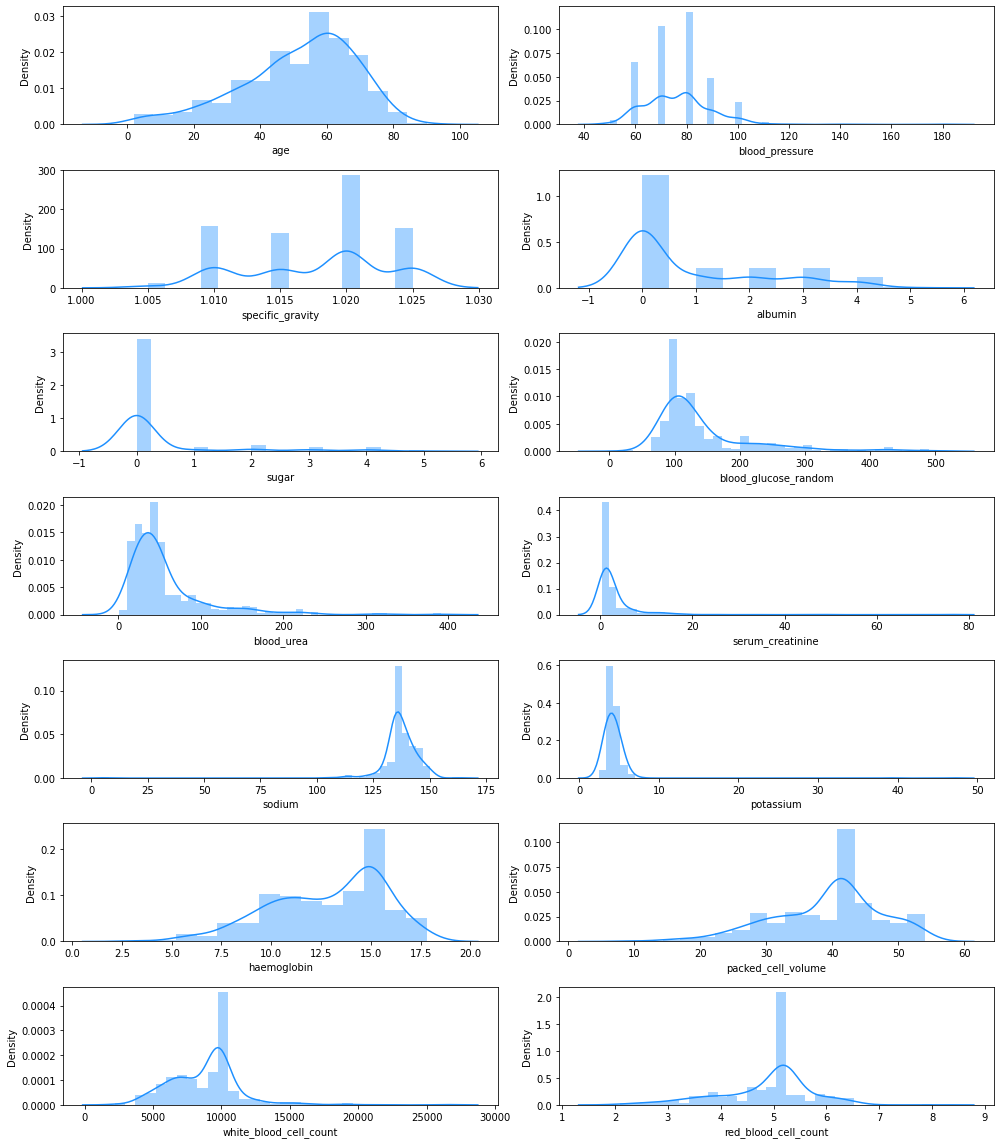

In [33]:
# checking numerical features distribution

plt.figure(figsize = (14, 16))
plotnumber = 1

for column in num_cols:
    if plotnumber <= 14:
        plt.subplot(7, 2, plotnumber)
        sns.distplot(df[column],color='dodgerblue')
        plt.xlabel(column)
        
    plotnumber += 1

plt.tight_layout()
plt.show()


In [ ]:
# Modelling

In [34]:
df.head(10)

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,...,diabetes_mellitus_no,diabetes_mellitus_yes,coronary_artery_disease_no,coronary_artery_disease_yes,appetite_good,appetite_poor,peda_edema_no,peda_edema_yes,aanemia_no,aanemia_yes
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,1.2,135.0,3.5,...,0,1,1,0,1,0,1,0,1,0
1,7.0,50.0,1.020,4.0,0.0,99.0,18.0,0.8,135.0,3.5,...,1,0,1,0,1,0,1,0,1,0
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,1.8,135.0,3.5,...,0,1,1,0,0,1,1,0,0,1
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.5,...,1,0,1,0,0,1,0,1,0,1
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,1.4,135.0,3.5,...,1,0,1,0,1,0,1,0,1,0
5,60.0,90.0,1.015,3.0,0.0,74.0,25.0,1.1,142.0,3.2,...,0,1,1,0,1,0,0,1,1,0
6,68.0,70.0,1.010,0.0,0.0,100.0,54.0,24.0,104.0,4.0,...,1,0,1,0,1,0,1,0,1,0
7,24.0,80.0,1.015,2.0,4.0,410.0,31.0,1.1,135.0,3.5,...,0,1,1,0,1,0,0,1,1,0
8,52.0,100.0,1.015,3.0,0.0,138.0,60.0,1.9,135.0,3.5,...,0,1,1,0,1,0,1,0,0,1
9,53.0,90.0,1.020,2.0,0.0,70.0,107.0,7.2,114.0,3.7,...,0,1,1,0,0,1,1,0,0,1


In [35]:
# Split train and test sets
from sklearn import model_selection,linear_model, metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


Y = df['class']
X = df.drop('class',axis=1)

x_train, x_test, y_train, y_test = model_selection.train_test_split(X, Y, random_state=42, test_size=.30)

In [36]:
# Performance comparision 1

In [56]:
# Define a model assess function to test model performance
def model_assess(model,name='Default'):
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    acc = accuracy_score(y_test, model.predict(x_test))
    print('\x1b[1;31m'+name+'\x1b[0m','\n',)
    print(f"Training Accuracy is {accuracy_score(y_train, model.predict(x_train))}")
    print(f"Test Accuracy is {acc} \n")
    print(f"Confusion Matrix :- \n{confusion_matrix(y_test, model.predict(x_test))}\n")
    print(classification_report(y_test,pred),'\n')
    

In [57]:
# KNN
knn = KNeighborsClassifier()
model_assess(knn,name="KNN")

# Logistic Regression
lg = LogisticRegression(random_state=42)
model_assess(lg,name="Logistic Regression")

# Decision tree
dtree = DecisionTreeClassifier()
model_assess(dtree,name="Decision Tree")

#Random Forest
rf=RandomForestClassifier(max_depth = 11, max_features = 'auto', min_samples_leaf = 2, min_samples_split = 3, n_estimators = 130)
model_assess(rf,name="Random Forest")

#XGBoost
xgb=XGBClassifier(objective = 'binary:logistic', random_state=42)
model_assess(xgb,name="XGBoost")

KNN 

Training Accuracy is 0.825
Test Accuracy is 0.7416666666666667 

Confusion Matrix :- 
[[50 26]
 [ 5 39]]

              precision    recall  f1-score   support

           0       0.91      0.66      0.76        76
           1       0.60      0.89      0.72        44

    accuracy                           0.74       120
   macro avg       0.75      0.77      0.74       120
weighted avg       0.80      0.74      0.75       120
 

Logistic Regression 

Training Accuracy is 0.9035714285714286
Test Accuracy is 0.9 

Confusion Matrix :- 
[[71  5]
 [ 7 37]]

              precision    recall  f1-score   support

           0       0.91      0.93      0.92        76
           1       0.88      0.84      0.86        44

    accuracy                           0.90       120
   macro avg       0.90      0.89      0.89       120
weighted avg       0.90      0.90      0.90       120
 

Decision Tree 

Training Accuracy is 1.0
Test Accuracy is 0.9916666666666667 

Confusion Matrix :- 
[[75

Minimum error: - 0.20833333333333334 at K =  5


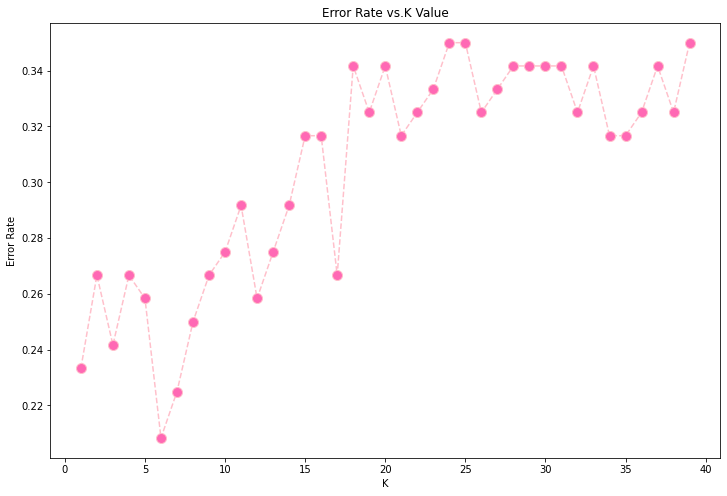

In [48]:
# KNN, find best K-value
error_rate = []
for i in range(1,40):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(x_train,y_train)
    pred_i = knn.predict(x_test)
    error_rate.append(np.mean(pred_i !=y_test))
    
plt.figure(figsize=(12,8))
plt.plot(range(1,40),error_rate,color='pink',linestyle='dashed',
        marker='o',markerfacecolor='hotpink',markersize=10)
plt.title('Error Rate vs.K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
print("Minimum error: -", min(error_rate),"at K = ", error_rate.index(min(error_rate)))

In [60]:
# Decision Tree, addressing overfit by adjusting max_depth, min_samples_leaf,min_samples_split 
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
DT = DecisionTreeClassifier(random_state = 42)
score = cross_val_score(DT,x_train,y_train,cv=10).mean()
print('Gini: %.4f'%score)
DT = DecisionTreeClassifier(criterion = 'entropy',random_state = 42)
score = cross_val_score(DT,x_train,y_train,cv=10).mean()
print('Entropy: %.4f'%score)

Gini: 0.9714
Entropy: 0.9857


Best: [5.         0.97142857]


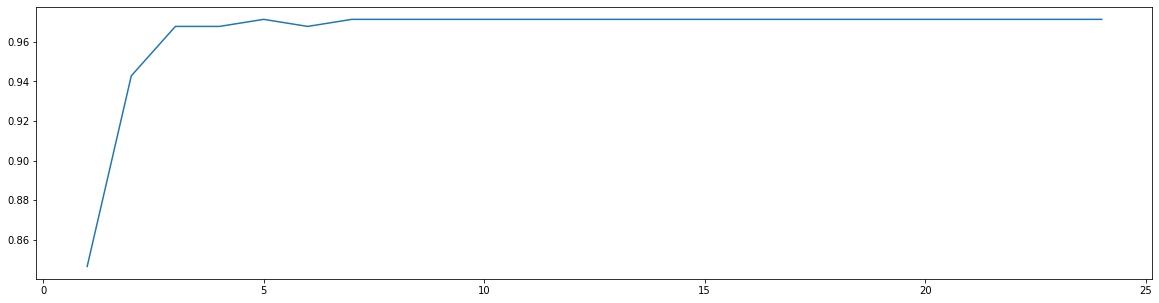

In [62]:
# Decision Tree.Find best Max depth
ScoreAll = []
for i in range(1,25):
    DT = DecisionTreeClassifier(max_depth = i,random_state = 42)
    score = cross_val_score(DT,x_train,y_train,cv=10).mean()
    ScoreAll.append([i,score])
ScoreAll = np.array(ScoreAll)

max_score = np.where(ScoreAll==np.max(ScoreAll[:,1]))[0][0] 
print("Best:",ScoreAll[max_score])  
# print(ScoreAll[,0])
plt.figure(figsize=[20,5])
plt.plot(ScoreAll[:,0],ScoreAll[:,1])
plt.show()

Best: [2.         0.97142857]


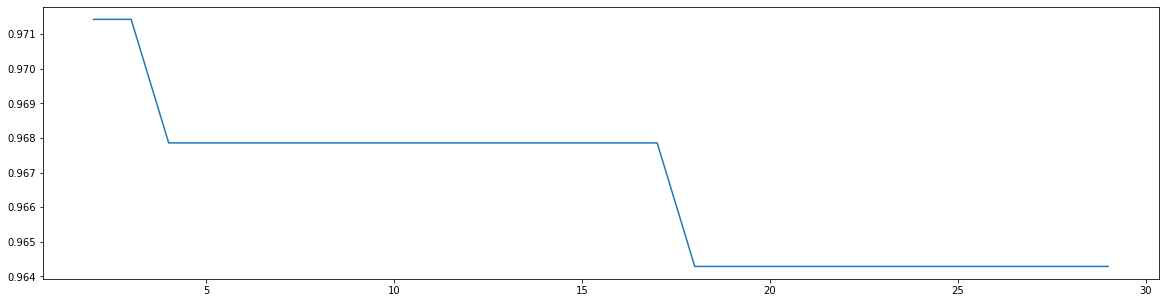

In [65]:
# Decision Tree.Find Best Min depth
ScoreAll = []
for i in range(2,30):
    DT = DecisionTreeClassifier(max_depth = 5,min_samples_split = i,random_state = 42)
    score = cross_val_score(DT,x_train,y_train,cv=10).mean()
    ScoreAll.append([i,score])
ScoreAll = np.array(ScoreAll)

max_score = np.where(ScoreAll==np.max(ScoreAll[:,1]))[0][0] 
print("Best:",ScoreAll[max_score])  
# print(ScoreAll[,0])
plt.figure(figsize=[20,5])
plt.plot(ScoreAll[:,0],ScoreAll[:,1])
plt.show()

Best: [8.         0.97142857]


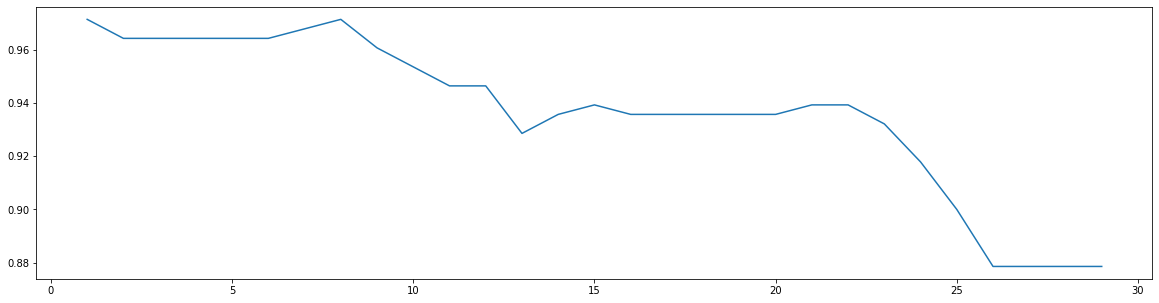

In [67]:
# Decision Tree.Find best min_samples_leaf
ScoreAll = []
for i in range(1,30):
    DT = DecisionTreeClassifier(min_samples_leaf = i,min_samples_split = 2,max_depth = 5,random_state = 42)
    score = cross_val_score(DT,x_train,y_train,cv=10).mean()
    ScoreAll.append([i,score])
ScoreAll = np.array(ScoreAll)

max_score = np.where(ScoreAll==np.max(ScoreAll[:,1]))[0][0] 
print("Best:",ScoreAll[max_score])  
# print(ScoreAll[,0])
plt.figure(figsize=[20,5])
plt.plot(ScoreAll[:,0],ScoreAll[:,1])
plt.show()

In [70]:
#Decision Tree.max_depth, min_samples_leaf,min_samples_split 
param_grid = {
    'max_depth':np.arange(3, 7),
    'min_samples_leaf':np.arange(0, 4),
    'min_samples_split':np.arange(6, 10)}

rfc = DecisionTreeClassifier(random_state=42)
GS = GridSearchCV(rfc,param_grid,cv=10)
GS.fit(x_train,y_train)
print(GS.best_params_)
print(GS.best_score_)

{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 6}
0.9678571428571429


Max Score：1.0 Subtree：31


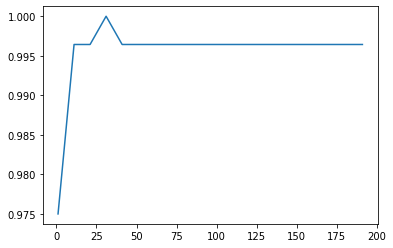

In [77]:
# Random Forest, find better n_estimators
score_lt = []
for i in range(0,200,10):
    rfc = RandomForestClassifier(n_estimators=i+1
                                ,random_state=42)
    score = cross_val_score(rfc, x_train, y_train, cv=10).mean()
    score_lt.append(score)
score_max = max(score_lt)
print('Max Score：{}'.format(score_max),
      'Subtree：{}'.format(score_lt.index(score_max)*10+1))
x = np.arange(1,201,10)
plt.subplot(111)
plt.plot(x, score_lt, '-')
plt.show()

Max Score：1.0 Subtree：34


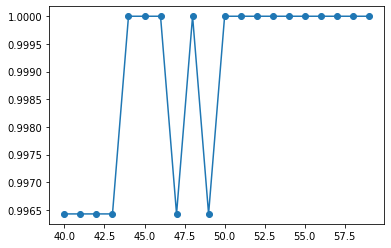

In [78]:
# Random Forest, find better n_estimators near 31
score_lt = []
for i in range(20,40):
    rfc = RandomForestClassifier(n_estimators=i
                                ,random_state=42)
    score = cross_val_score(rfc, x_train, y_train, cv=10).mean()
    score_lt.append(score)
score_max = max(score_lt)
print('Max Score：{}'.format(score_max),
      'Subtree：{}'.format(score_lt.index(score_max)+30))

x = np.arange(40,60)
plt.subplot(111)
plt.plot(x, score_lt,'o-')
plt.show()

In [80]:
# Random Forest, find better max_depth
rfc = RandomForestClassifier(n_estimators=34, random_state=90)


param_grid = {'max_depth':np.arange(1,20)}
GS = GridSearchCV(rfc, param_grid, cv=10)
GS.fit(x_train, y_train)

best_param = GS.best_params_
best_score = GS.best_score_
print(best_param, best_score)

{'max_depth': 7} 1.0


In [82]:
# Random Forest, find better max_features
param_grid = {'max_features':np.arange(5,35)}

rfc = RandomForestClassifier(n_estimators=34
                            ,random_state=42
                            ,max_depth=7)
GS = GridSearchCV(rfc, param_grid, cv=10)
GS.fit(x_train, y_train)
best_param = GS.best_params_
best_score = GS.best_score_
print(best_param, best_score) 

{'max_features': 5} 1.0


In [85]:
# KNN
knn = KNeighborsClassifier(n_neighbors = 5)
model_assess(knn,name="KNN")

# Logistic Regression
lg = LogisticRegression(random_state=42)
model_assess(lg,name="Logistic Regression")

# Decision tree
dtree = DecisionTreeClassifier(max_depth = 3,min_samples_leaf=1, min_samples_split=2)
model_assess(dtree,name="Decision Tree")

#Random Forest
rf=RandomForestClassifier(max_depth = 3, max_features = 5, n_estimators = 34)
model_assess(rf,name="Random Forest")

#XGBoost
xgb=XGBClassifier(objective = 'binary:logistic', random_state=42)
model_assess(xgb,name="XGBoost")

KNN 

Training Accuracy is 0.825
Test Accuracy is 0.7416666666666667 

Confusion Matrix :- 
[[50 26]
 [ 5 39]]

              precision    recall  f1-score   support

           0       0.91      0.66      0.76        76
           1       0.60      0.89      0.72        44

    accuracy                           0.74       120
   macro avg       0.75      0.77      0.74       120
weighted avg       0.80      0.74      0.75       120
 

Logistic Regression 

Training Accuracy is 0.9035714285714286
Test Accuracy is 0.9 

Confusion Matrix :- 
[[71  5]
 [ 7 37]]

              precision    recall  f1-score   support

           0       0.91      0.93      0.92        76
           1       0.88      0.84      0.86        44

    accuracy                           0.90       120
   macro avg       0.90      0.89      0.89       120
weighted avg       0.90      0.90      0.90       120
 

Decision Tree 

Training Accuracy is 0.9892857142857143
Test Accuracy is 0.9833333333333333 

Confusion 

In [104]:
# Display feature and their importance by Random Forest

feature_scores = 100*pd.Series(rf.feature_importances_, index=x_train.columns).sort_values(ascending=False)
feature_scores

serum_creatinine               20.570130
specific_gravity               15.038878
packed_cell_volume             11.711375
haemoglobin                     8.188487
diabetes_mellitus_yes           5.769539
hypertension_no                 5.697052
hypertension_yes                5.645915
diabetes_mellitus_no            5.123451
albumin                         5.101464
blood_glucose_random            3.864867
blood_urea                      2.600061
sodium                          1.946770
white_blood_cell_count          1.766113
appetite_poor                   1.516118
red_blood_cell_count            1.332089
blood_pressure                  1.166051
age                             0.909377
potassium                       0.777199
appetite_good                   0.572585
sugar                           0.329621
pus_cell_abnormal               0.172371
pus_cell_normal                 0.123925
red_blood_cells_normal          0.076562
bacteria_present                0.000000
bacteria_notpres

In [103]:
# Display feature and their importance by xgboost
feat_imp = xgb.get_booster().get_score(importance_type='weight')

import operator as op
feat_imp = dict(sorted(feat_imp.items(), key=op.itemgetter(1),reverse=True))
feat_imp

{'haemoglobin': 27.0,
 'serum_creatinine': 26.0,
 'packed_cell_volume': 23.0,
 'sodium': 19.0,
 'potassium': 17.0,
 'white_blood_cell_count': 15.0,
 'specific_gravity': 11.0,
 'blood_pressure': 6.0,
 'albumin': 6.0,
 'blood_glucose_random': 6.0,
 'blood_urea': 6.0,
 'diabetes_mellitus_no': 3.0,
 'age': 1.0,
 'red_blood_cell_count': 1.0}